# Worksheet 3: Modelling the Neuron
## From MCP to Perceptron, Its Learning Algorithm, and Limitations


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Task 1: Implementing MCP Neurons


#### AND Gate
For AND to output 1, **both** inputs must be 1.  
So the sum must be **≥ 2**, meaning we set **Threshold T = 2**.


In [2]:
def MCP_Neurons_AND(X1, X2, T):
    """
    Implements AND logic using an MCP Neuron.

    Arguments:
        X1 (list): Binary input array (0s and 1s)
        X2 (list): Binary input array
        T  (int) : Threshold value

    Returns:
        state_neuron (list): Output of the neuron (0 or 1) for each input pair
    """
    assert len(X1) == len(X2), "Both input arrays must be the same length"

    # Step 1: Element-wise addition of inputs
    input_sum = [X1[i] + X2[i] for i in range(len(X1))]

    # Step 2: Apply threshold to get neuron output
    state_neuron = []
    for s in input_sum:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 2  # Threshold for AND: both inputs must be 1

result_and = MCP_Neurons_AND(X1, X2, T)
print(f"AND gate output for inputs {X1} and {X2} with threshold {T}: {result_and}")


AND gate output for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 2: [0, 0, 0, 1]


#### OR Gate
For OR to output 1, **at least one** input must be 1.  
So the sum must be **≥ 1**, meaning we set **Threshold T = 1**.


In [3]:
def MCP_Neurons_OR(X1, X2, T):
    """
    Implements OR logic using an MCP Neuron.

    Arguments:
        X1 (list): Binary input array (0s and 1s)
        X2 (list): Binary input array
        T  (int) : Threshold value

    Returns:
        state_neuron (list): Output of the neuron (0 or 1) for each input pair
    """
    assert len(X1) == len(X2), "Both input arrays must be the same length"

    # Step 1: Element-wise addition of inputs
    input_sum = [X1[i] + X2[i] for i in range(len(X1))]

    # Step 2: Apply threshold to get neuron output
    state_neuron = []
    for s in input_sum:
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron

X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T  = 1  # Threshold for OR: at least one input must be 1

result_or = MCP_Neurons_OR(X1, X2, T)
print(f"OR gate output for inputs {X1} and {X2} with threshold {T}: {result_or}")


OR gate output for inputs [0, 0, 1, 1] and [0, 1, 0, 1] with threshold 1: [0, 1, 1, 1]


### Questions on MCP Neurons

**Question 1: List all the limitations of MCP Neurons.**

1. The threshold T must be set manually. There is no automatic learning, the designer has to figure out the right value.
2. Every input is treated the same. In real neurons, some inputs matter more than others but MCP cannot represent this difference.
3. MCP only accepts 0 or 1 as inputs. It cannot handle real-valued (continuous) data.
4. It only outputs 0 or 1. It cannot produce probabilities or gradual responses.
5. The MCP neuron cannot learn from data. Weights and threshold are set by hand and never updated.
6. It fails on problems like XOR, where a single straight line cannot separate the two classes.
7. If any input is inhibitory, the output is always 0, no matter what the other inputs say. This is too rigid.




**Question 2: Can you solve XOR using a single MCP Neuron?**

**No**, a single MCP Neuron cannot solve XOR.

The XOR truth table is:

| X1 | X2 | XOR Output |
|----|----|------------|
|  0 |  0 |     0      |
|  0 |  1 |     1      |
|  1 |  0 |     1      |
|  1 |  1 |     0      |

For an MCP neuron, we compute `sum = X1 + X2` and compare to threshold T:
- If T = 1 → outputs 0,1,1,1 → that's OR, not XOR
- If T = 2 → outputs 0,0,0,1 → that's AND, not XOR

There is no threshold value that gives us [0, 1, 1, 0].  
This is because XOR is not linearly separable, we cannot draw a single straight line to separate 0s from 1s.

**To solve XOR**, we need two MCP neurons combined:  
- Neuron 1: AND (T=2)  
- Neuron 2: OR (T=1)  
- Combine: OR output AND NOT(AND output) → XOR

```
XOR(X1, X2) = OR(X1, X2) AND NOT(AND(X1, X2))
```


### Task 2: Perceptron for 0 vs 1 Classification (MNIST)


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AI ML/Data/mnist_0_and_1.csv")

# Extract features (pixel values) and labels
X = df_0_1.drop(columns=["label"]).values   # Shape: (n_samples, 784)
y = df_0_1["label"].values                  # Shape: (n_samples,)

print("Feature matrix shape:", X.shape)
print("Label vector shape:  ", y.shape)


Feature matrix shape: (12665, 784)
Label vector shape:   (12665,)


**Question 1: What does the shape of X represent?**

X.shape gives us (number of images, 784).  
- **first number** = how many images are in the dataset  
- **784** = each image is 28×28 pixels, flattened into a single row of 784 numbers  
So each row in X is one image, and each column is one pixel's brightness value.

**Question 2: What does the shape of y represent?**

y.shape gives us (number of images,).  
It is a 1D array where each value is the label(0 or 1) for the corresponding image in X.


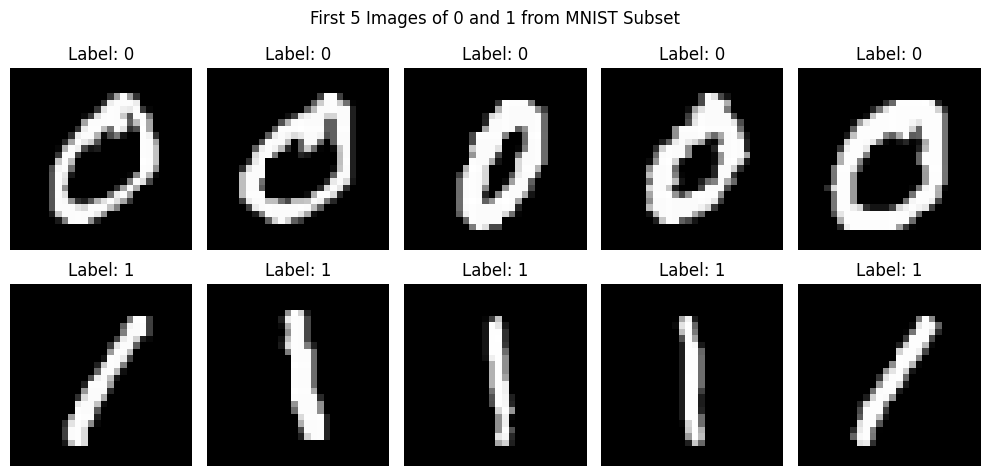

In [6]:
# Separate images by label
images_0 = X[y == 0]   # All images of digit 0
images_1 = X[y == 1]   # All images of digit 1

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images to display.")
else:
    for i in range(5):
        # Row 1: digit 0
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        # Row 2: digit 1
        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

plt.suptitle("First 5 Images of 0 and 1 from MNIST Subset")
plt.tight_layout()
plt.show()


In [7]:
# Initialize weights and bias to zero
weights       = np.zeros(X.shape[1])   # 784 weights, one per pixel
bias          = 0
learning_rate = 0.1
epochs        = 100

print("Weights shape:", weights.shape)
print("Bias:", bias)


Weights shape: (784,)
Bias: 0


**Question 3: What does the weights array represent?**

The weights array has **784 values** - one for each pixel of the image.  
Each weight tells the perceptron how important that pixel is for making a decision.  
A large positive weight means that pixel strongly suggests class 1, a large negative weight suggests class 0.  
Initially, all weights are 0 (we have not learned anything yet).




**Question 4: Why are we initializing weights to zero? What effect could this have?**

We start all weights at 0 because:
- It is a simple, neutral starting point - the model has no bias toward any class yet.
- For a single perceptron, zero initialization works fine because the weight updates depend on errors, and errors will appear immediately since all predictions start the same.

**Potential issue:** If we used zero initialization in a multi-layer neural network, all neurons would compute the same output and receive the same gradient update - they would never learn different features. This is called the **symmetry problem**. For a single perceptron, it is acceptable.

In [8]:
def decision_function(X, weights, bias):
    """
    Compute the predicted labels for the input data using the step function.

    Parameters:
        X       : Input features, shape (n_samples, n_features)
        weights : Learned weight array, shape (n_features,)
        bias    : Learned bias value (scalar)

    Returns:
        y_pred_all : Predicted labels (0 or 1) for each sample
    """
    # Compute the weighted sum (dot product) + bias for all samples at once
    predictions = np.dot(X, weights) + bias

    # Apply activation function: output 1 if >= 0, else 0
    y_pred_all = np.where(predictions >= 0, 1, 0)

    return y_pred_all


In [9]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    """
    Train the perceptron using the Perceptron Learning Algorithm.

    Parameters:
        X             : Input features, shape (n_samples, n_features)
        y             : True labels, shape (n_samples,)
        weights       : Initial weights, shape (n_features,)
        bias          : Initial bias (scalar)
        learning_rate : Step size for weight updates (default 0.1)
        epochs        : Number of passes over the dataset (default 100)

    Returns:
        weights  : Updated weights after training
        bias     : Updated bias after training
        accuracy : Final accuracy on training data (fraction of correct predictions)
    """

    for epoch in range(epochs):
        convergence = True   # Assume no errors this epoch

        for i in range(len(X)):
            # Step 1: Compute weighted sum for sample i
            output = np.dot(X[i], weights) + bias

            # Step 2: Apply step function to get prediction
            y_pred = 1 if output >= 0 else 0

            # Step 3: If prediction is wrong, update weights and bias
            if y_pred != y[i]:
                error = y[i] - y_pred                    # error is +1 or -1
                weights = weights + learning_rate * error * X[i]
                bias    = bias    + learning_rate * error
                convergence = False                      # Still making errors

        # If no mistakes were made in this epoch, stop early
        if convergence:
            print(f"Converged at epoch {epoch + 1}")
            break

    # Calculate final accuracy on the full training set
    final_predictions = decision_function(X, weights, bias)
    accuracy = np.mean(final_predictions == y)

    return weights, bias, accuracy


**Question 5: What is the purpose of output = np.dot(X[i], weights) + bias?**

This line computes the weighted sum for sample `i`.  
`np.dot(X[i], weights)` multiplies each pixel value by its corresponding weight and sums them all up.  
Adding `bias` shifts this sum, allowing the decision boundary to move away from the origin.  
The result (`output`) is then compared to 0 to decide the predicted class.



**Question 6: What happens when the prediction is wrong? How are weights and bias updated?**

When `y_pred != y[i]` (wrong prediction):
- `error = y[i] - y_pred` → either +1 (predicted 0, should be 1) or -1 (predicted 1, should be 0)
- `weights = weights + learning_rate × error × X[i]` → pixels that were "active" (high value) get their weights pushed in the correct direction
- `bias = bias + learning_rate × error` → the bias shifts to better separate the classes

This nudges the decision boundary to correctly classify the misclassified sample.



**Question 7: Why is final accuracy important, and what do you expect it to be?**

Final accuracy tells us how well the perceptron learned to separate the two classes on training data.  
For 0 vs 1 classification, we expect very high accuracy (close to 100%) because:
- Digits 0 and 1 look very different visually
- They are linearly separable, a straight line (hyperplane) in pixel space can cleanly divide them
- The perceptron is guaranteed to converge when data is linearly separable


In [10]:
# Re-initialize weights and bias before training (fresh start)
weights = np.zeros(X.shape[1])
bias    = 0

# Train the perceptron
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100)

print(f"Final Training Accuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)")


Converged at epoch 13
Final Training Accuracy: 1.0000  (100.00%)


In [11]:
# Get predictions for all samples
y_pred = decision_function(X, weights, bias)

# Final accuracy
final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

# Find misclassified indices
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images (0 vs 1)")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")


Final Accuracy: 1.0000
All images were correctly classified!


**Question 8: What does `misclassified_idx` store, and how is it used?**

`misclassified_idx` stores the index positions of all samples where the predicted label does not match the true label.  
`np.where(y_pred != y)[0]` scans through every sample and returns the indices where predictions were wrong.  
These indices are then used to retrieve the actual images (`X[idx]`) and display them in a grid so we can visually inspect which samples confused the model.




**Question 9: How do you interpret "All images were correctly classified!"?**

This means the perceptron achieved 100% training accuracy. It made no mistakes on any of the training samples.  
For 0 vs 1 classification, this is expected because these two digits are visually very different and linearly separable.  
The perceptron learning theorem guarantees that if data is linearly separable, the algorithm will find a perfect decision boundary in a finite number of steps.  
Note: This is accuracy on **training data**; performance on unseen test data may differ.

## Task 3: Perceptron Algorithm for 3 vs 5 Classification (MNIST)

Now we repeat the same steps for digits **3 and 5**, which are much more visually similar making this a harder classification problem.


In [12]:
# Load the 3 vs 5 dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/AI ML/Data/mnist_3_and_5.csv")

# Extract features and labels
X2 = df_3_5.drop(columns=["label"]).values
y2 = df_3_5["label"].values

# Convert labels: treat 3 → 0 and 5 → 1 for binary classification
y2_binary = np.where(y2 == 3, 0, 1)

print("Feature matrix shape:", X2.shape)
print("Label vector shape:  ", y2.shape)
print("Unique labels:", np.unique(y2))


Feature matrix shape: (2741, 784)
Label vector shape:   (2741,)
Unique labels: [3 5]


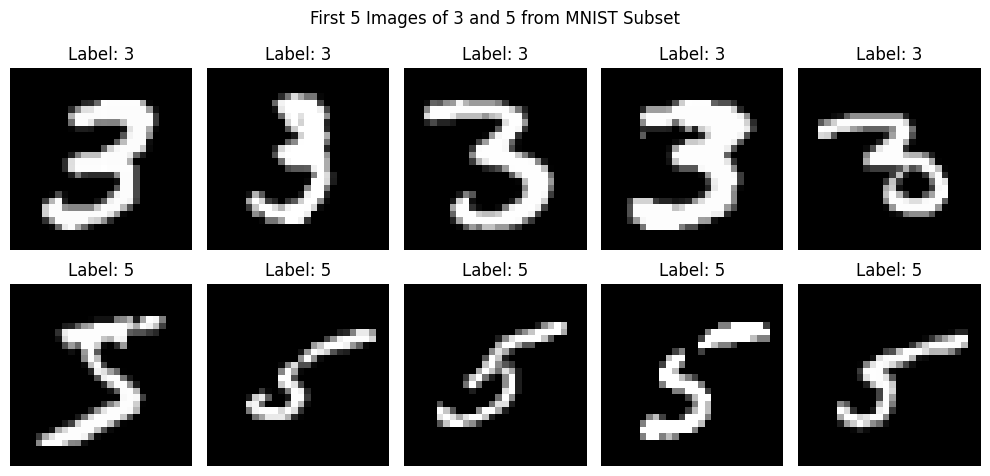

In [13]:
# Visualize first 5 images of each digit
images_3 = X2[y2 == 3]
images_5 = X2[y2 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(5):
    axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
    axes[0, i].set_title("Label: 3")
    axes[0, i].axis("off")

    axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Label: 5")
    axes[1, i].axis("off")

plt.suptitle("First 5 Images of 3 and 5 from MNIST Subset")
plt.tight_layout()
plt.show()


In [14]:
# Initialize weights and bias for 3 vs 5 task
weights2 = np.zeros(X2.shape[1])
bias2    = 0

# Train the perceptron
weights2, bias2, accuracy2 = train_perceptron(X2, y2_binary, weights2, bias2, learning_rate=0.1, epochs=100)

print(f"Final Training Accuracy (3 vs 5): {accuracy2:.4f}  ({accuracy2*100:.2f}%)")


Final Training Accuracy (3 vs 5): 0.9869  (98.69%)


Final Accuracy (3 vs 5): 0.9869
Number of misclassified images: 36


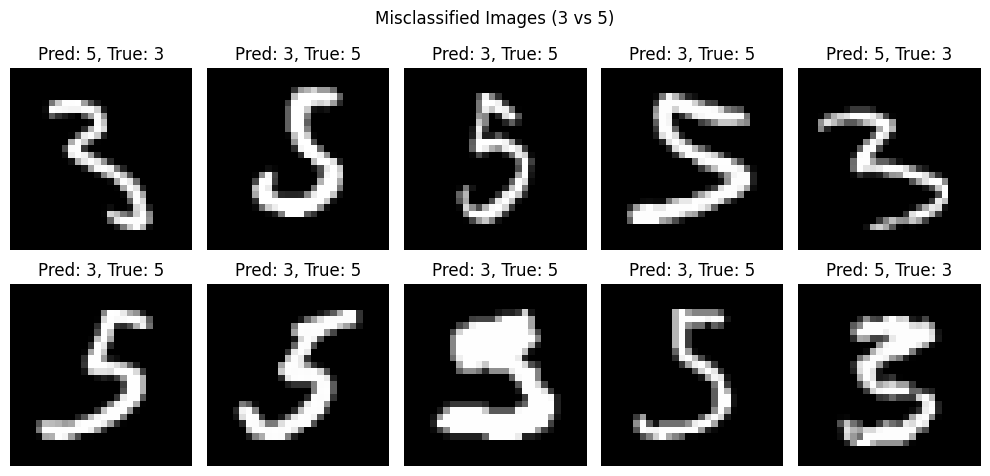

In [15]:
# Get predictions for 3 vs 5
y2_pred = decision_function(X2, weights2, bias2)

# Final accuracy
final_accuracy2 = np.mean(y2_pred == y2_binary)
print(f"Final Accuracy (3 vs 5): {final_accuracy2:.4f}")

# Find and visualize misclassified images
misclassified_idx2 = np.where(y2_pred != y2_binary)[0]

if len(misclassified_idx2) > 0:
    print(f"Number of misclassified images: {len(misclassified_idx2)}")

    # Map binary predictions back to original labels for display
    pred_labels = np.where(y2_pred == 0, 3, 5)
    true_labels = y2   # Original labels (3 or 5)

    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx2[:10]):
        ax.imshow(X2[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {pred_labels[idx]}, True: {true_labels[idx]}")
        ax.axis("off")

    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")


### Conclusion: 3 vs 5 Classification

The 3 vs 5 classification is harder than 0 vs 1 because:
- Digits 3 and 5 look visually similar. Both have curved strokes and can be confused even by humans.
- They may not be perfectly linearly separable in pixel space, meaning a single straight decision boundary may not work for every sample.

As a result:
- We expect lower accuracy compared to the 0 vs 1 task.
- There will be more misclassified images, especially for handwritten digits that are written in ambiguous styles (e.g., a sloppily written 3 can look like a 5).
- The misclassified images often show digits written in unusual ways that straddle the decision boundary.

It can only solve **linearly separable** problems. For more complex cases, we need multi-layer networks (like MLPs) that can learn non-linear boundaries.
